In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from algorithms.neural_network import neural_network
from algorithms.auxiliares import *

In [4]:
ruta_data = os.path.abspath('../data')

X_train, y_train = cargar_datos_csv(os.path.join(ruta_data, 'iris81_trn.csv'), 3)
X_test, y_test = cargar_datos_csv(os.path.join(ruta_data, 'iris81_tst.csv'), 3)

X_train, X_test = np.array(X_train), np.array(X_test)
y_train, y_test = np.array(y_train), np.array(y_test)

print(X_train.shape)
print(y_train.shape)

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train_norm = (X_train - mean) / std
X_test_norm  = (X_test  - mean) / std

(111, 4)
(111, 3)


In [5]:
model = neural_network(
    layers_config = [(5, 'symmetry sigmoid'), (3, 'symmetry sigmoid'), (3, 'symmetry sigmoid')],
    size_input = X_train_norm.shape[1],
    max_epoch=300,
    learning_rate=0.005,
    error_threshold=1e-3)

model.fit(X_train_norm, y_train)

y_pred = model.transform(X_test_norm)

print(model.score(X_test_norm, y_test))

1.0


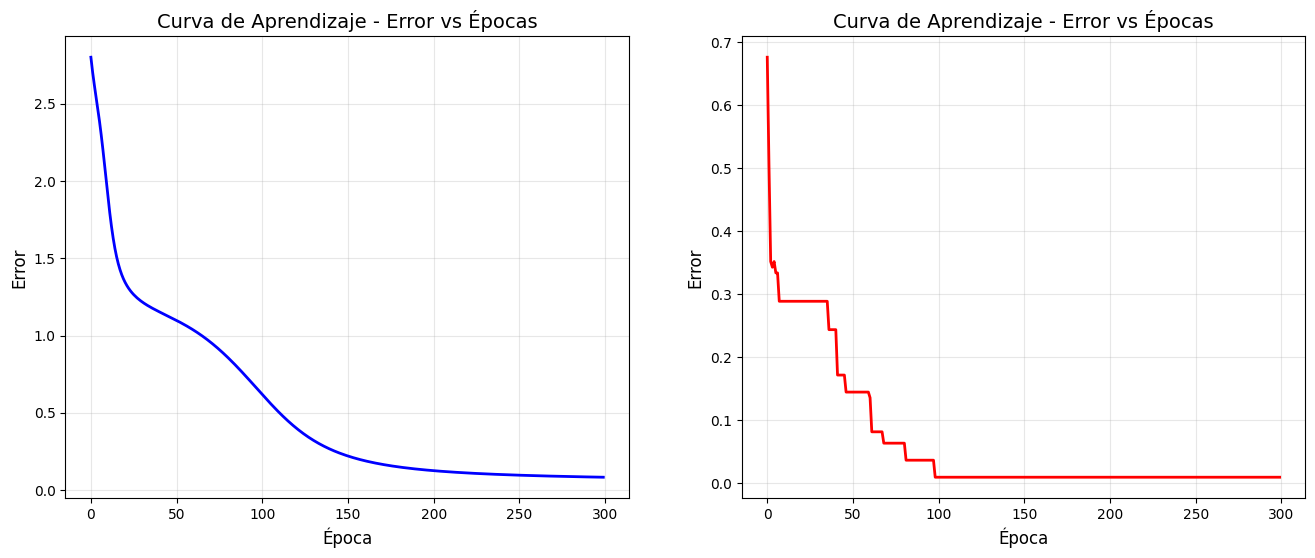

In [6]:
plt.figure(figsize=(16, 6))
plt.subplot(1,2,1)
plt.plot(model.epoch_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(model.epoch_classification_error, color='red', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
alfas = [
    0.0025, 0.001, 0.005, 0.01
]
modelos = []

for i in range(len(alfas)):
    modelo = neural_network(
        layers_config = [
            (5, 'symmetry sigmoid'),
            (3, 'symmetry sigmoid'),
            (3, 'symmetry sigmoid')
        ],
        size_input = X_train_norm.shape[1],
        max_epoch=1000,
        learning_rate=alfas[i],
        error_threshold=1e-3)

    modelo.fit(X_train_norm, y_train)
    modelos.append(modelo)

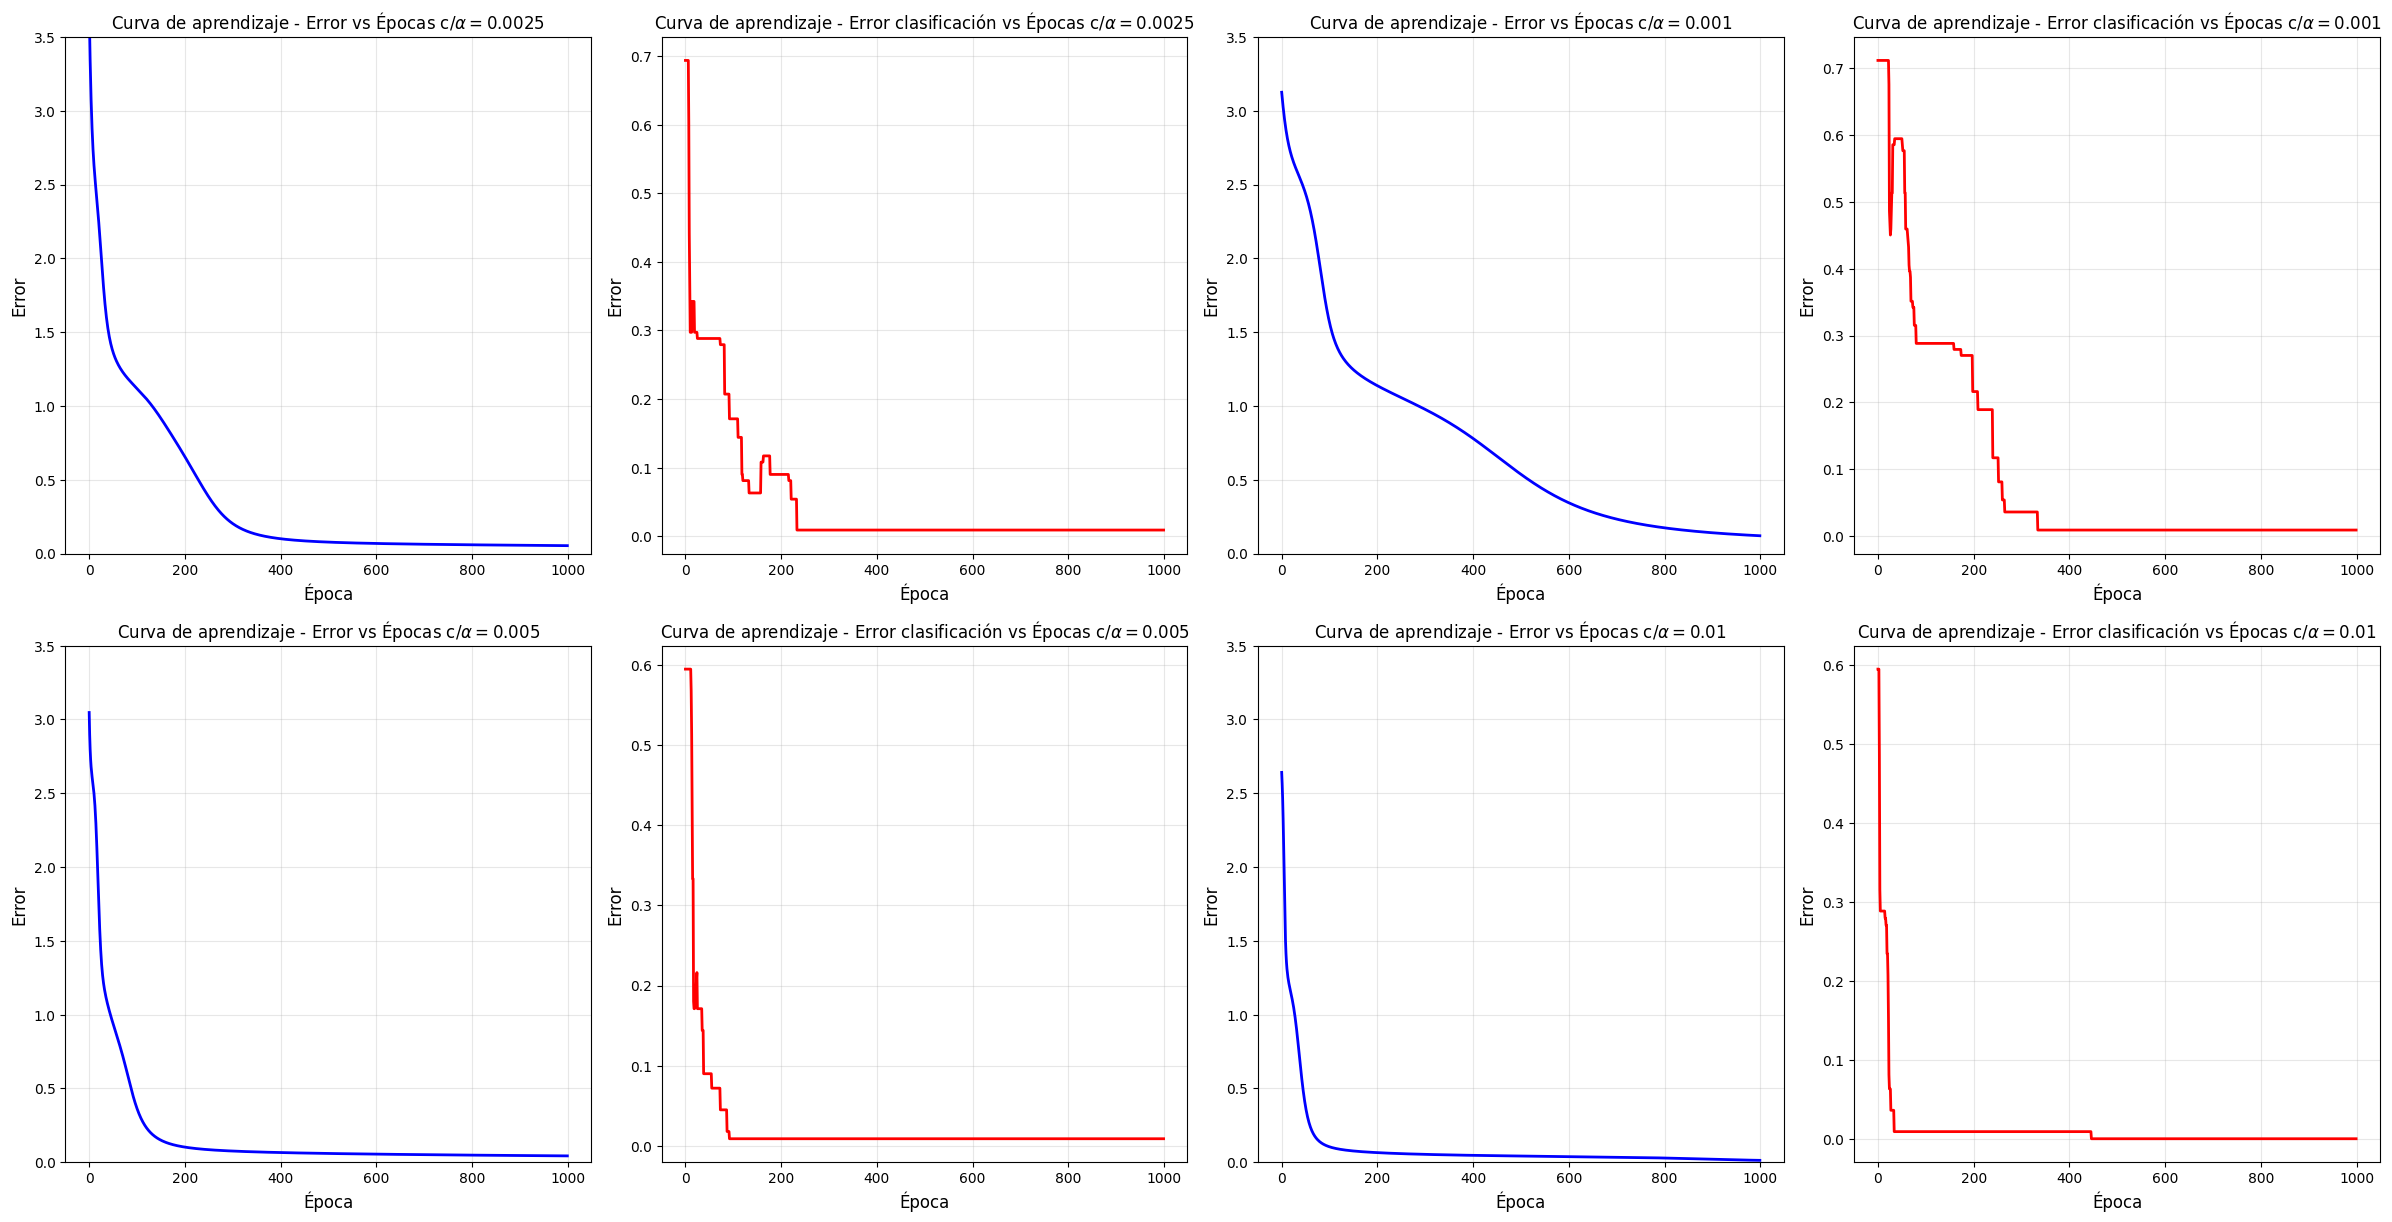

In [8]:
plt.figure(figsize=(24,24))

for i in range(len(alfas)):
    plt.subplot(4,4,i*2+1)
    plt.title(f"Curva de aprendizaje - Error vs Épocas c/$\\alpha={alfas[i]}$")
    plt.plot(modelos[i].epoch_error, color='blue', linewidth=2)
    plt.xlabel('Época', fontsize=12)
    plt.ylabel('Error', fontsize=12)
    plt.ylim(0, 3.5)
    plt.grid(True, alpha=0.3)

    plt.subplot(4,4,i*2+2)
    plt.title(f"Curva de aprendizaje - Error clasificación vs Épocas c/$\\alpha={alfas[i]}$")
    plt.plot(modelos[i].epoch_classification_error, color='red', linewidth=2)
    plt.xlabel('Época', fontsize=12)
    plt.ylabel('Error', fontsize=12)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

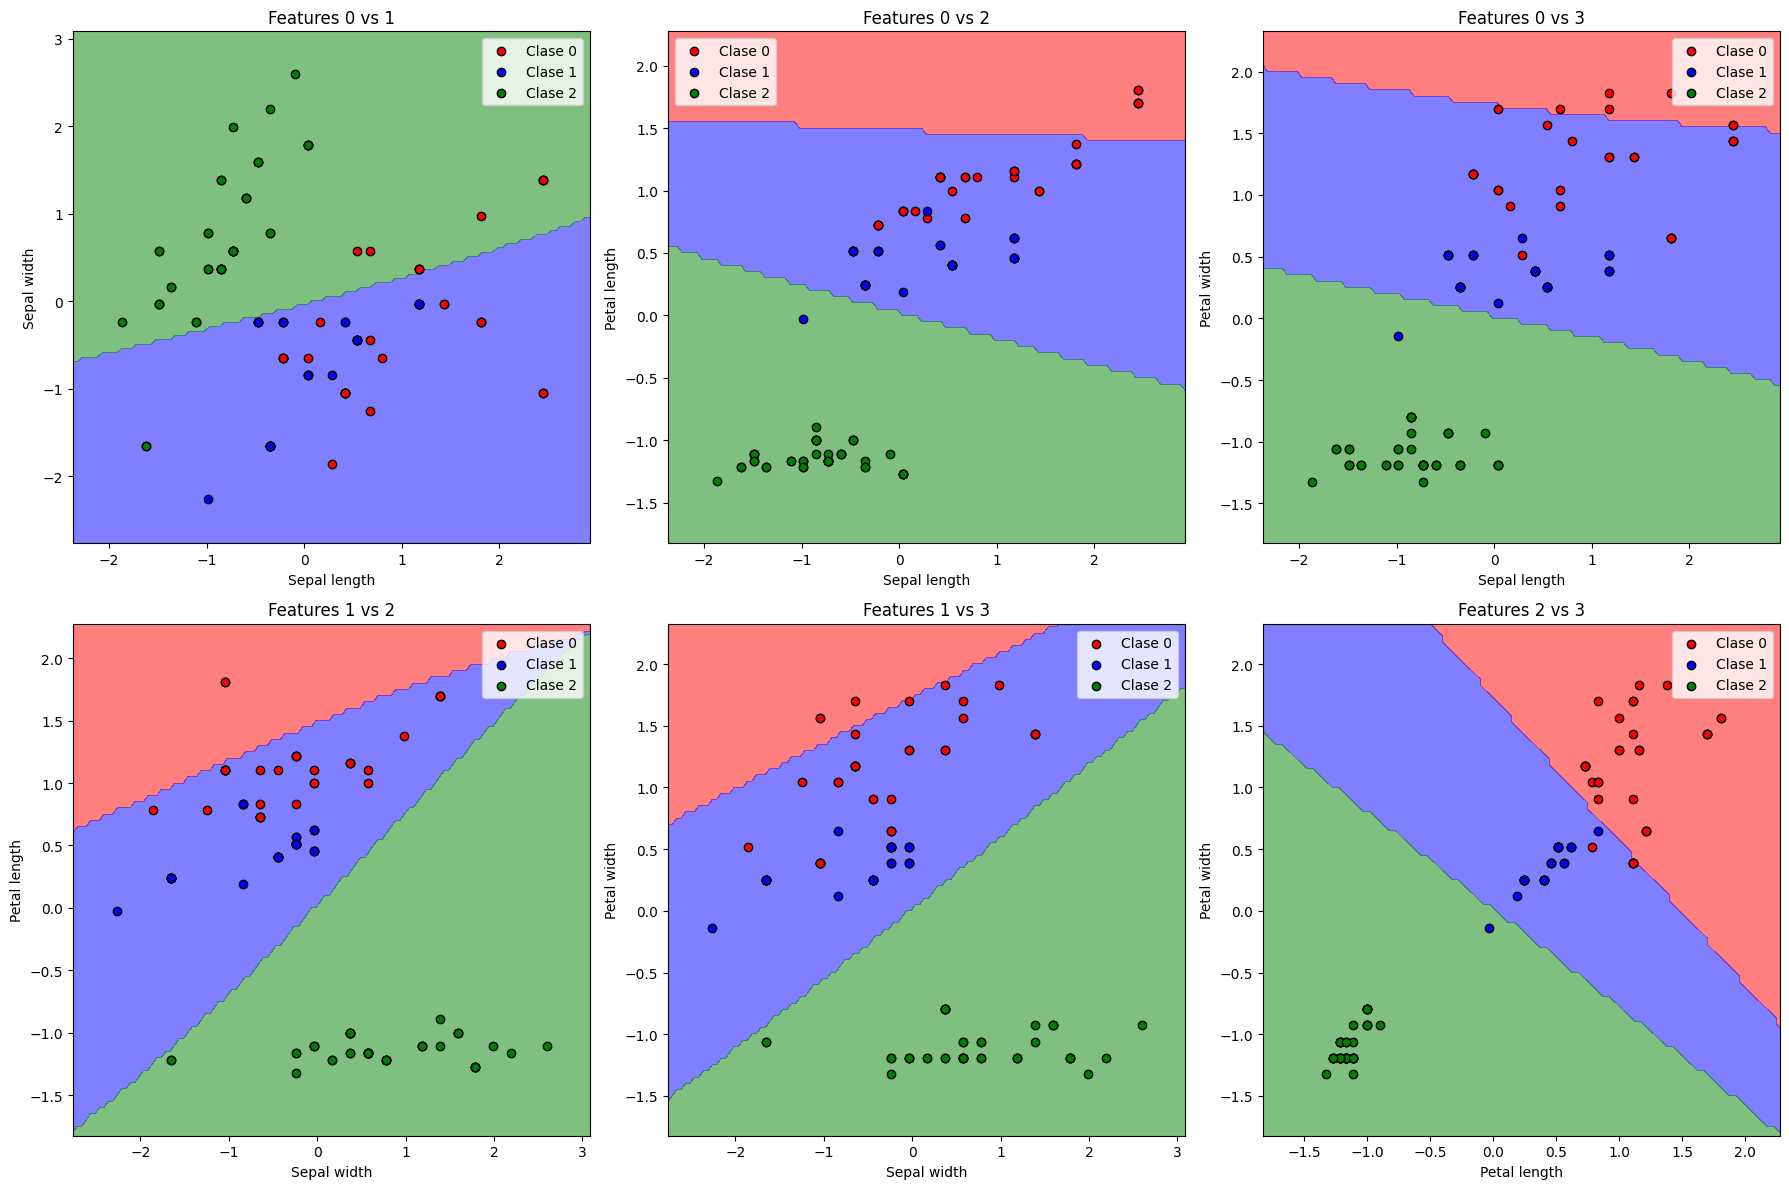

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from matplotlib.colors import ListedColormap

# nombres opcionales (para que quede lindo)
feature_names = ['Sepal length', 'Sepal width', 'Petal length', 'Petal width']

# combinaciones de pares de features
pairs = list(itertools.combinations(range(4), 2))

mean = np.mean(X_train_norm, axis=0)

plt.figure(figsize=(18, 12))

for idx, (i, j) in enumerate(pairs):
    plt.subplot(2, 3, idx+1)

    # rango de la grilla
    x_min, x_max = X_train_norm[:, i].min() - 0.5, X_train_norm[:, i].max() + 0.5
    y_min, y_max = X_train_norm[:, j].min() - 0.5, X_train_norm[:, j].max() + 0.5

    resolucion = 0.05
    xx = np.arange(x_min, x_max, resolucion)
    yy = np.arange(y_min, y_max, resolucion)

    X_malla, Y_malla = np.meshgrid(xx, yy)

    Z = []

    for x_val, y_val in zip(X_malla.ravel(), Y_malla.ravel()):
        punto = mean.copy()
        punto[i] = x_val
        punto[j] = y_val

        salida = model.transform(punto.reshape(1, -1))
        clase = np.argmax(salida)

        Z.append(clase)

    Z = np.array(Z).reshape(X_malla.shape)

    # contour con 3 clases
    cmap = ListedColormap(['red', 'blue', 'green'])

    plt.contourf(
        X_malla, 
        Y_malla, 
        Z, 
        levels=[-0.5, 0.5, 1.5, 2.5],  # define límites claros entre clases
        cmap=cmap, 
        alpha=0.5
    )
    # scatter de puntos reales
    y_classes = np.argmax(y_train, axis=1)

    colores = ['red', 'blue', 'green']

    for clase in range(3):
        plt.scatter(
            X_train_norm[y_classes == clase][:, i],
            X_train_norm[y_classes == clase][:, j],
            color=colores[clase],
            label=f'Clase {clase}',
            edgecolors='black'
        )

    plt.xlabel(feature_names[i])
    plt.ylabel(feature_names[j])
    plt.title(f'Features {i} vs {j}')
    plt.legend()

plt.tight_layout()
plt.show()